# Module 2: Simple Regression Project

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

%matplotlib inline

## Step 1: Explore Data

In [ ]:
df = pd.read_csv("../data/combined_monthly.csv")
# df = pd.read_csv('../data/combined_monthly.csv') does not perform well

print("First 5 rows:")
display(df.head())

print("\nDataFrame info:")
df.info()

print("\nSummary statistics:")
display(df.describe(include="all"))

First 5 rows:


,Date,SP500,Crude_Oil,US_10Y_Yield,Copper,Steel_PPI,CPI,Unemployment_Rate
0,2011-01-01,1286.119995,92.190002,3.378,4.4510,220.4,221.187,9.1
1,2011-02-01,1327.219971,96.970001,3.414,4.4780,239.8,221.898,9.0
2,2011-03-01,1325.829956,106.720001,3.454,4.3000,248.1,223.046,9.0
3,2011-04-01,1363.609985,113.930000,3.296,4.1655,257.3,224.093,9.1
4,2011-06-01,1320.640015,95.419998,3.158,4.2720,250.3,224.806,9.1



DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138 entries, 0 to 137
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               138 non-null    object 
 1   SP500              138 non-null    float64
 2   Crude_Oil          138 non-null    float64
 3   US_10Y_Yield       138 non-null    float64
 4   Copper             138 non-null    float64
 5   Steel_PPI          138 non-null    float64
 6   CPI                138 non-null    float64
 7   Unemployment_Rate  138 non-null    float64
dtypes: float64(7), object(1)
memory usage: 8.8+ KB

Summary statistics:


,Date,SP500,Crude_Oil,US_10Y_Yield,Copper,Steel_PPI,CPI,Unemployment_Rate
count,138,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000
unique,138,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2011-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2745.952669,71.411716,2.375324,3.264586,284.949266,254.738938,5.544681
std,NaN,1123.776175,21.554810,0.879383,0.701885,123.640735,25.799390,1.915688
min,NaN,1131.420044,33.619999,0.809500,2.064000,170.300000,221.187000,3.400000
25%,NaN,1920.915009,51.802499,1.741500,2.659375,217.375000,236.229500,3.800000
50%,NaN,2513.105103,72.450001,2.275500,3.164500,228.700000,246.859500,4.900000
75%,NaN,3767.594910,91.932501,2.791000,3.797375,315.681500,264.615500,7.275000


## Step 2: Split Data

In [9]:
df["Date"] = pd.to_datetime(df["Date"])
numeric_df = df.select_dtypes(include=[np.number]).copy()

target_col = "SP500"
feature_candidates = [c for c in numeric_df.columns if c != target_col]

if not feature_candidates:
    raise ValueError("No numeric feature columns available for simple regression.")

# Pick one feature for simple regression: highest absolute correlation with SP500.
abs_corr = numeric_df[feature_candidates].corrwith(numeric_df[target_col]).abs().sort_values(ascending=False)
best_feature = abs_corr.index[0]

X = numeric_df[[best_feature]]
y = numeric_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Selected feature: {best_feature}")
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Selected feature: CPI
Train shape: (110, 1), Test shape: (28, 1)


## Step 3: Develop and Fit the Model

In [10]:
model = LinearRegression()
model.fit(X_train, y_train)

print(f"Intercept: {model.intercept_:.4f}")
print(f"Coefficient for {best_feature}: {model.coef_[0]:.4f}")

Intercept: -7467.1741
Coefficient for CPI: 39.9735


## Step 4: Predict Using the Model

In [11]:
y_pred = model.predict(X_test)

print("Predicted SP500 (first 10):")
print(np.round(y_pred[:10], 2))

Predicted SP500 (first 10):
[2812.21 3261.04 1679.05 1842.66 2286.52 2333.65 2292.88 4321.53 3481.97
 2509.3 ]


## Step 5: Evaluate the Accuracy

### Plot Prediction Results and Calculate Metrics

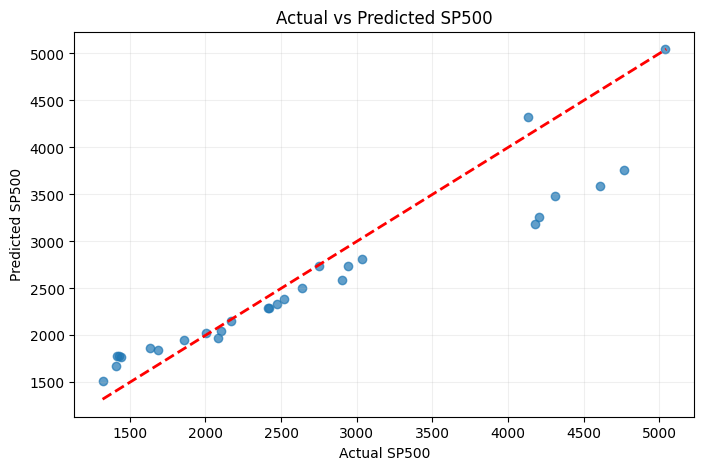

MSE: 196076.0819
MAE: 306.9851
RMSE: 442.8048
R^2: 0.8462


In [13]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.7)

line_min = min(y_test.min(), y_pred.min())
line_max = max(y_test.max(), y_pred.max())
plt.plot([line_min, line_max], [line_min, line_max], "r--", linewidth=2)

plt.xlabel("Actual SP500")
plt.ylabel("Predicted SP500")
plt.title("Actual vs Predicted SP500")
plt.grid(alpha=0.2)
plt.show()

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R^2: {r2:.4f}")